# Ejemplo aplicado: regresión lineal — Wine Quality (red)

Misma plantilla que [01-regresion-lineal.ipynb](../01-regresion-lineal.ipynb), ya configurada para `wine_quality_red.csv` (target `quality`, separador `;`).

> Para un CSV nuevo, parte de la **plantilla genérica** `01-regresion-lineal.ipynb`, no de este archivo.


In [1]:
# --- Imports: librerías usadas en todo el notebook ---
import warnings

import matplotlib.pyplot as plt  # Gráficos (EDA, comparación de modelos)
import numpy as np
import pandas as pd  # Carga y exploración del CSV
import seaborn as sns
from sklearn.compose import ColumnTransformer  # Preprocesado distinto por tipo de columna
from sklearn.impute import SimpleImputer  # Rellenar valores faltantes (NaN)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline  # Encadena pasos: preprocess → modelo
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


def infer_feature_columns(df, target_col, drop_cols, feature_cols):
    """Devuelve la lista de columnas que entrarán como X (features).

    Si FEATURE_COLS está definido en CONFIG, usa esa lista.
    Si no, toma todas las columnas excepto el target y DROP_COLS (ids, leakage, etc.).
    """
    if feature_cols is not None:
        return list(feature_cols)
    exclude = {target_col, *drop_cols}
    return [c for c in df.columns if c not in exclude]


def infer_column_types(X, numeric_cols=None, categorical_cols=None):
    """Separa columnas numéricas y categóricas para el ColumnTransformer.

    Por defecto: int/float → numéricas; object/category/bool/string → categóricas.
    Puedes forzar listas en CONFIG (NUMERIC_COLS / CATEGORICAL_COLS) si pandas
    no detecta bien el tipo (p. ej. códigos postales guardados como número).
    """
    if numeric_cols is None:
        numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if categorical_cols is None:
        categorical_cols = X.select_dtypes(
            include=["object", "category", "bool", "string"]
        ).columns.tolist()
    return list(numeric_cols), list(categorical_cols)


def build_preprocess(numeric_cols, categorical_cols):
    """Construye el preprocesador compartido por TODOS los modelos del benchmark.

    - Numéricas: imputar → escalar.
    - Categóricas: imputar → codificar.

    El fit solo se hace en train (dentro de pipe.fit); en test solo transform,
    para no filtrar información del conjunto de evaluación (data leakage).
    """
    transformers = []

    # --- Rama numérica ---
    if numeric_cols:
        transformers.append(
            (
                "num",
                Pipeline(
                    [
                        # Imputer: rellena NaN. Alternativas de strategy:
                        #   "mean", "median" (robusto a outliers), "most_frequent", constant
                        ("imputer", SimpleImputer(strategy="median")),
                        # Escalado: media 0, std 1. Alternativas:
                        #   MinMaxScaler (rango [0,1]), RobustScaler (outliers),
                        #   Normalizer (por fila). Sin escalar: quitar este paso.
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_cols,
            )
        )

    # --- Rama categórica ---
    if categorical_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        # Moda para categóricas faltantes
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "encoder",
                            # One-hot: una columna binaria por categoría.
                            # Alternativas:
                            #   OrdinalEncoder — orden fijo (talla S,M,L); ahorra columnas
                            #   TargetEncoder — media del target por categoría (cuidado leakage;
                            #                   usar solo dentro del Pipeline en train)
                            # handle_unknown="ignore": en test, categorías nuevas → ceros
                            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                        ),
                    ]
                ),
                categorical_cols,
            )
        )

    if not transformers:
        raise ValueError("No hay columnas numéricas ni categóricas para preprocesar.")
    # remainder="drop": columnas no listadas se descartan (no entran al modelo)
    return ColumnTransformer(transformers, remainder="drop")

def split_train_val_test(X, y, test_size, val_size, random_state, stratify=False):
    """Divide en train, validación y test (dos llamadas a train_test_split).

    - test_size: fracción del total para test (hold-out final, paso 9).
    - val_size: fracción de train+val; el benchmark (paso 8) usa solo val.
    Con test_size=0.2 y val_size=0.25 → ~60 % train, ~20 % val, ~20 % test.
    """
    kw = dict(test_size=test_size, random_state=random_state)
    if stratify:
        kw["stratify"] = y
    X_tv, X_test, y_tv, y_test = train_test_split(X, y, **kw)
    kw2 = dict(test_size=val_size, random_state=random_state)
    if stratify:
        kw2["stratify"] = y_tv
    X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, **kw2)
    return X_train, X_val, X_test, y_train, y_val, y_test





## 1. Explorar el CSV (antes de CONFIG)

Ejecuta esta celda con un CSV nuevo **solo** para ver columnas, tipos y faltantes. Con eso rellenas `TARGET_COL`, `DROP_COLS`, etc. en la celda siguiente.

Si el `head()` se ve mal (todo en una columna), cambia `PREVIEW_SEP` a `","`, `";"` o `"\t"`.


In [2]:
# Ruta y separador del CSV (único ajuste antes de ver la tabla)
PREVIEW_PATH = "../data/wine_quality_red.csv"
PREVIEW_SEP = ";"  # Prueba: ","  |  ";"  |  "\t"

df_preview = pd.read_csv(PREVIEW_PATH, sep=PREVIEW_SEP)

print(f"Filas: {len(df_preview):,}  |  Columnas: {len(df_preview.columns)}")
print("\n--- Nombres de columnas (índice : nombre) ---")
for i, col in enumerate(df_preview.columns):
    print(f"  {i:2d}: {col!r}")

print("\n--- Tipos de datos (dtypes) ---")
print(df_preview.dtypes)

print("\n--- Primeras filas ---")
display(df_preview.head())

print("\n--- Valores faltantes por columna ---")
missing = df_preview.isna().sum()
if missing.any():
    display(missing[missing > 0].to_frame("nulos"))
else:
    print("No hay valores faltantes.")

# Sugerencia para NUMERIC_COLS / CATEGORICAL_COLS en CONFIG (si dejas None, se infieren igual)
_num = df_preview.select_dtypes(include=[np.number]).columns.tolist()
_cat = df_preview.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()
print("\n--- Sugerencia automática de tipos ---")
print("Numéricas (int/float):", _num)
print("Categóricas (object/category/bool/string):", _cat)

print(
    "\n>>> Siguiente paso: en CONFIG usa el mismo PREVIEW_PATH → DATA_PATH, "
    "PREVIEW_SEP → CSV_SEP, y elige TARGET_COL (columna numérica a predecir)."
)


Filas: 1,599  |  Columnas: 12

--- Nombres de columnas (índice : nombre) ---
   0: 'fixed acidity'
   1: 'volatile acidity'
   2: 'citric acid'
   3: 'residual sugar'
   4: 'chlorides'
   5: 'free sulfur dioxide'
   6: 'total sulfur dioxide'
   7: 'density'
   8: 'pH'
   9: 'sulphates'
  10: 'alcohol'
  11: 'quality'

--- Tipos de datos (dtypes) ---
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

--- Primeras filas ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



--- Valores faltantes por columna ---
No hay valores faltantes.

--- Sugerencia automática de tipos ---
Numéricas (int/float): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Categóricas (object/category/bool/string): []

>>> Siguiente paso: en CONFIG usa el mismo PREVIEW_PATH → DATA_PATH, PREVIEW_SEP → CSV_SEP, y elige TARGET_COL (columna numérica a predecir).


## 2. CONFIG


In [3]:
# ========== CONFIG (editar al cambiar de dataset) ==========
# Mismos valores que PREVIEW_PATH y PREVIEW_SEP en la celda de exploración
DATA_PATH = "../data/wine_quality_red.csv"
# Ejemplo otro archivo: DATA_PATH = "../data/mi_tabla.csv"

CSV_SEP = ";"
# Ejemplos: "," (estándar)  |  ";" (wine quality, muchos exports europeos)  |  "\t" (TSV)

# Columna que quieres PREDECIR (variable continua en regresión)
TARGET_COL = "quality"
# Ejemplos: "precio", "mpg", "MedHouseVal", "salario"

# Columnas que NO deben usarse como features (ids, texto libre, duplicados del target)
DROP_COLS = []
# Ejemplos: ["id", "id_vivienda"]  |  ["PassengerId", "Name"] (Titanic, si el target es Survived)

# Si None: todas las columnas salvo TARGET_COL y DROP_COLS
FEATURE_COLS = None
# Ejemplo manual: FEATURE_COLS = ["alcohol", "volatile acidity", "sulphates"]

# Si None: se infieren por tipo (int/float vs object/category)
NUMERIC_COLS = None
# Ejemplo: NUMERIC_COLS = ["edad", "ingresos", "hijos"]

CATEGORICAL_COLS = None
# Ejemplo: CATEGORICAL_COLS = ["ciudad", "tipo_contrato", "color"]

# Fracción para test (0.2 = 20 % test, 80 % train)
TEST_SIZE = 0.2  # fracción total para test (hold-out final)
VAL_SIZE = 0.25  # fracción de train+val → validación (~20 % del total si TEST_SIZE=0.2)
RANDOM_STATE = 42

# Métrica para ordenar la tabla de comparación (mayor R² = mejor en regresión)
METRIC_PRINCIPAL = "r2"
CV_FOLDS = 5  # K-fold en train (paso 8); val/test no participan



def build_models():
    """Diccionario nombre → estimador. Comenta líneas para excluir modelos del benchmark."""
    from sklearn.ensemble import (
        GradientBoostingRegressor,
        HistGradientBoostingRegressor,
        RandomForestRegressor,
    )
    from sklearn.linear_model import Lasso, LinearRegression, Ridge
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.neighbors import KNeighborsRegressor
    from xgboost import XGBRegressor
    from catboost import CatBoostRegressor

    models = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(random_state=RANDOM_STATE),
        "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=5000),
        "DecisionTree": DecisionTreeRegressor(
            criterion="squared_error",
            splitter="best",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            min_weight_fraction_leaf=0.0,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=RANDOM_STATE,
        ),
        "RandomForest": RandomForestRegressor(
            n_estimators=100,
            criterion="squared_error",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            min_weight_fraction_leaf=0.0,
            max_features=1.0,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            bootstrap=True,
            oob_score=False,
            max_samples=None,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        "KNN": KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
        "XGBoost": XGBRegressor(
            random_state=RANDOM_STATE, verbosity=0, n_estimators=100, n_jobs=-1
        ),
        "CatBoost": CatBoostRegressor(
            random_state=RANDOM_STATE,
            verbose=False,
            iterations=100,
            allow_writing_files=False,
        ),
    }
    return models


MODELS = build_models()



## 3. Carga de datos


In [4]:
df = pd.read_csv(DATA_PATH, sep=CSV_SEP)
print("Shape:", df.shape)
df.head()


Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 4. Calidad de datos


In [5]:
print(df.info())
print("\nFaltantes por columna:")
missing = df.isna().sum()
print(missing[missing > 0] if missing.any() else "Sin valores faltantes")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Faltantes por columna:
Sin valores faltantes


## 5. Análisis de features y dependencias

Explora la relación del **target** con las predictoras: histograma, scatter y **matriz de correlación** (solo tiene sentido en regresión; la matriz de confusión es para clasificación).



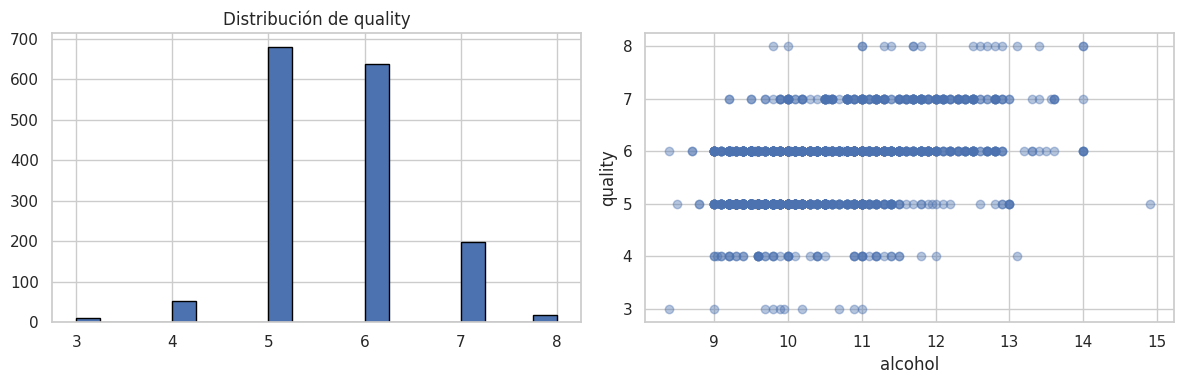

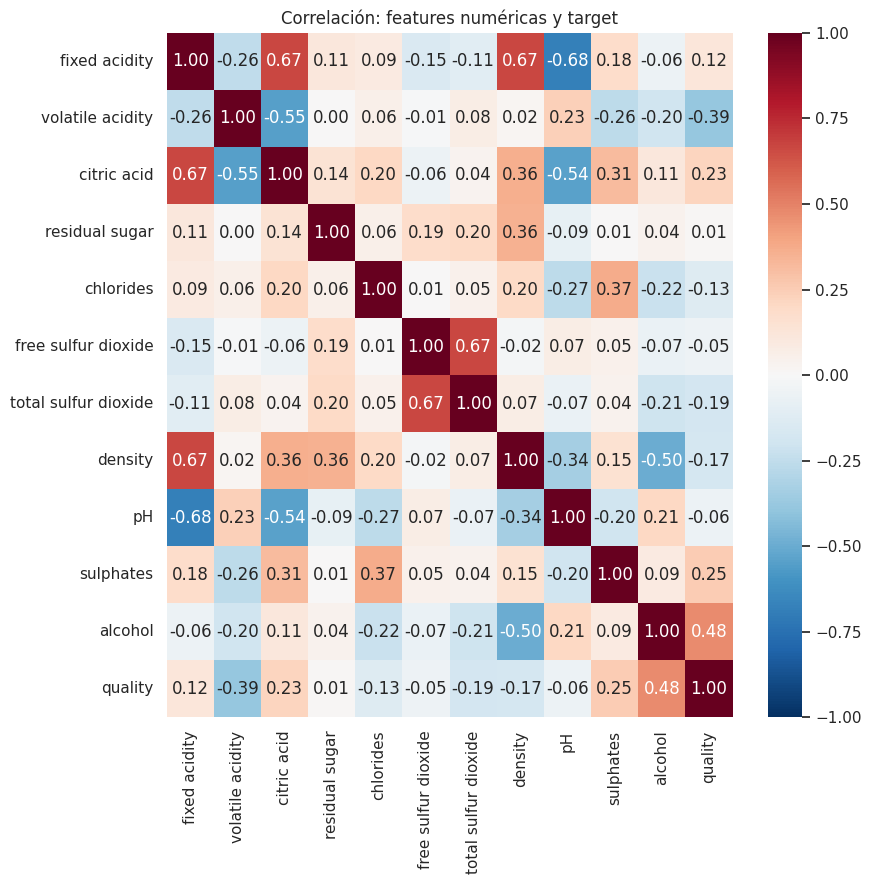

In [6]:
# --- Paso 5: análisis de features y dependencias con el target ---
feature_cols_eda = infer_feature_columns(df, TARGET_COL, DROP_COLS, FEATURE_COLS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[TARGET_COL].hist(ax=axes[0], bins=20, edgecolor="black")
axes[0].set_title(f"Distribución de {TARGET_COL}")
num_feat = df[feature_cols_eda].select_dtypes(include=[np.number]).columns
if len(num_feat):
    corrs = df[num_feat].corrwith(df[TARGET_COL]).abs().sort_values(ascending=False)
    feat = corrs.index[0] if len(corrs.dropna()) else num_feat[0]
    axes[1].scatter(df[feat], df[TARGET_COL], alpha=0.4)
    axes[1].set_xlabel(feat)
    axes[1].set_ylabel(TARGET_COL)
plt.tight_layout()
plt.show()

# --- Correlación entre features numéricas y target ---
num_cols = [
    c for c in feature_cols_eda
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
]
cols_corr = list(dict.fromkeys(num_cols + [TARGET_COL]))

top_feat = None
if len(cols_corr) >= 2 and pd.api.types.is_numeric_dtype(df[TARGET_COL]):
    corr = df[cols_corr].corr(numeric_only=True)
    size = max(5, 0.75 * len(cols_corr))
    fig, ax = plt.subplots(figsize=(size, size))
    sns.heatmap(
        corr,
        annot=len(cols_corr) <= 12,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        ax=ax,
    )
    ax.set_title("Correlación: features numéricas y target")
    plt.tight_layout()
    plt.show()
    s = corr[TARGET_COL].drop(TARGET_COL, errors="ignore").abs()
    if len(s):
        top_feat = s.idxmax()

if top_feat is None:
    others = [c for c in feature_cols_eda if c in df.columns and c != TARGET_COL]
    top_feat = others[0] if others else None



## 6. Separar X / y y split train-test


In [7]:
feature_cols = infer_feature_columns(df, TARGET_COL, DROP_COLS, FEATURE_COLS)
X = df[feature_cols]
y = df[TARGET_COL]
numeric_cols, categorical_cols = infer_column_types(X, NUMERIC_COLS, CATEGORICAL_COLS)

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)


X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
    X, y, test_size=TEST_SIZE, val_size=VAL_SIZE, random_state=RANDOM_STATE
)
print(
    f"Tamaños → train: {len(X_train):,} | val: {len(X_val):,} | test: {len(X_test):,}"
)



Numéricas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Categóricas: []
Tamaños → train: 959 | val: 320 | test: 320


## 7. Preprocesado (compartido por todos los modelos)


In [8]:
preprocess = build_preprocess(numeric_cols, categorical_cols)
preprocess


,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 8. Comparar modelos

Métricas en **train** y **val**; brecha train−val para detectar **overfitting**.

**Validación cruzada** estratificada en `X_train` (`CV_FOLDS` folds): `Pipeline` dentro de cada fold; val y test quedan fuera.



,modelo,mae_train,rmse_train,r2_train,mae_val,rmse_val,r2_val,gap_r2
3,RandomForest,0.1649,0.2335,0.9166,0.4297,0.6139,0.4062,0.5104
5,HistGradientBoosting,0.1533,0.2124,0.9310,0.4349,0.6231,0.3883,0.5427
7,CatBoost,0.2386,0.3115,0.8515,0.4729,0.6399,0.3548,0.4967
4,GradientBoosting,0.3714,0.4718,0.6594,0.4818,0.6407,0.3533,0.3062
6,XGBoost,0.0163,0.0255,0.9990,0.4181,0.6459,0.3428,0.6562
1,Ridge,0.5011,0.6463,0.3609,0.5005,0.6742,0.2838,0.0772
0,LinearRegression,0.5010,0.6463,0.3609,0.5005,0.6743,0.2836,0.0773
2,Lasso,0.6813,0.8085,0.0000,0.6855,0.8022,-0.0140,0.0140



Posible overfitting (gap r2 train-val > 0.15):


,modelo,r2_train,r2_val,gap_r2
3,RandomForest,0.9166,0.4062,0.5104
5,HistGradientBoosting,0.9310,0.3883,0.5427
7,CatBoost,0.8515,0.3548,0.4967
4,GradientBoosting,0.6594,0.3533,0.3062
6,XGBoost,0.9990,0.3428,0.6562


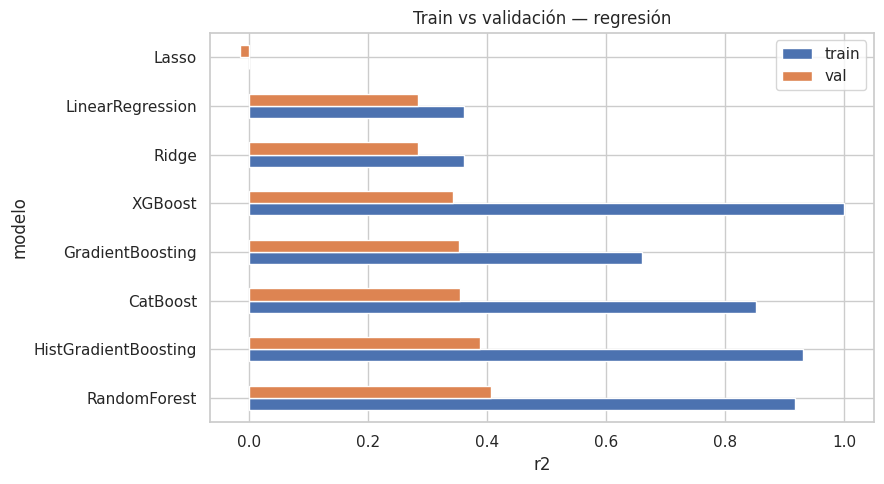

In [9]:
# --- Paso 8: métricas y benchmark de modelos ---

OVERFIT_GAP_WARN = 0.15  # brecha train-val en METRIC_PRINCIPAL por encima → posible overfitting
# R²: gap = train - val (mayor = peor generalización). MAE/RMSE: gap = val - train.

def regression_metrics(y_true, y_pred):
    """MAE, RMSE y R²."""
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {"mae": mae, "rmse": rmse, "r2": r2}


def _generalization_gap(m_train, m_val, metric):
    if metric == "r2":
        return m_train[metric] - m_val[metric]
    return m_val[metric] - m_train[metric]



def _cv_scoring(metric):
    """Métrica para sklearn.cross_validate (neg_* → se invierte al mostrar)."""
    return {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    }.get(metric, metric)


def evaluate_models_cv(models, preprocess, X, y, n_splits=CV_FOLDS):
    """Validación cruzada en train: Pipeline dentro de cada fold (sin leakage)."""
    from sklearn.model_selection import KFold, cross_validate

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    metric = METRIC_PRINCIPAL
    scoring = _cv_scoring(metric)
    rows = []
    for name, estimator in models.items():
        pipe = Pipeline([("preprocess", preprocess), ("model", estimator)])
        scores = cross_validate(
            pipe, X, y, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
        )
        tm = scores[f"train_{scoring}"]
        ts = scores[f"test_{scoring}"]
        if scoring.startswith("neg_"):
            tm, ts = -tm, -ts
        row = {
            "modelo": name,
            f"{metric}_cv_mean": ts.mean(),
            f"{metric}_cv_std": ts.std(),
            f"{metric}_train_cv_mean": tm.mean(),
        }
        if metric == "r2":
            row[f"gap_cv_{metric}"] = tm.mean() - ts.mean()
        rows.append(row)
    asc = metric not in ("r2",)
    return pd.DataFrame(rows).sort_values(f"{metric}_cv_mean", ascending=asc)

def evaluate_models(models, preprocess, X_train, X_val, y_train, y_val):
    """Entrena en train; métricas en train y val para detectar overfitting."""
    rows = []
    metric = METRIC_PRINCIPAL
    for name, estimator in models.items():
        pipe = Pipeline([("preprocess", preprocess), ("model", estimator)])
        pipe.fit(X_train, y_train)
        m_train = regression_metrics(y_train, pipe.predict(X_train))
        m_val = regression_metrics(y_val, pipe.predict(X_val))
        row = {"modelo": name}
        for k, v in m_train.items():
            row[f"{k}_train"] = v
        for k, v in m_val.items():
            row[f"{k}_val"] = v
        row[f"gap_{metric}"] = _generalization_gap(m_train, m_val, metric)
        rows.append(row)
    asc = metric not in ("r2",)
    return pd.DataFrame(rows).sort_values(f"{metric}_val", ascending=asc)


results = evaluate_models(MODELS, preprocess, X_train, X_val, y_train, y_val)
display(results.round(4))

gap_col = f"gap_{METRIC_PRINCIPAL}"
sospechosos = results[results[gap_col] > OVERFIT_GAP_WARN]
if len(sospechosos):
    print(
        f"\nPosible overfitting (gap {METRIC_PRINCIPAL} train-val > {OVERFIT_GAP_WARN}):"
    )
    display(
        sospechosos[
            ["modelo", f"{METRIC_PRINCIPAL}_train", f"{METRIC_PRINCIPAL}_val", gap_col]
        ].round(4)
    )
else:
    print(
        f"\nSin gap {METRIC_PRINCIPAL} train-val > {OVERFIT_GAP_WARN} "
        "(no hay señal fuerte de overfitting en el benchmark)."
    )

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = results.set_index("modelo")[
    [f"{METRIC_PRINCIPAL}_train", f"{METRIC_PRINCIPAL}_val"]
]
plot_df.plot(kind="barh", ax=ax)
ax.set_xlabel(METRIC_PRINCIPAL)
ax.set_title("Train vs validación — regresión")
ax.legend(["train", "val"])
plt.tight_layout()
plt.show()


print("\n--- Validación cruzada en train (val y test reservados) ---")
print(f"K={CV_FOLDS}; el Pipeline se ajusta en cada fold (sin leakage).")
cv_results = evaluate_models_cv(MODELS, preprocess, X_train, y_train)
display(cv_results.round(4))





## 9. Detalle del mejor modelo


Mejor modelo (val): RandomForest
Métricas en test (tras reentrenar con train+val):


,mae,rmse,r2
0,0.4306,0.5616,0.5175


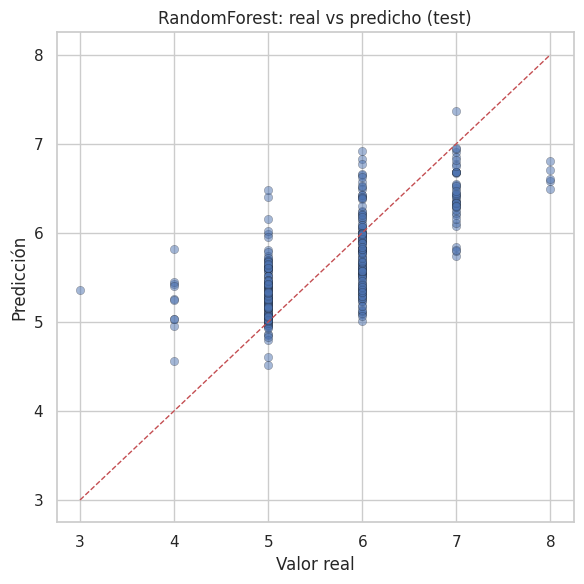

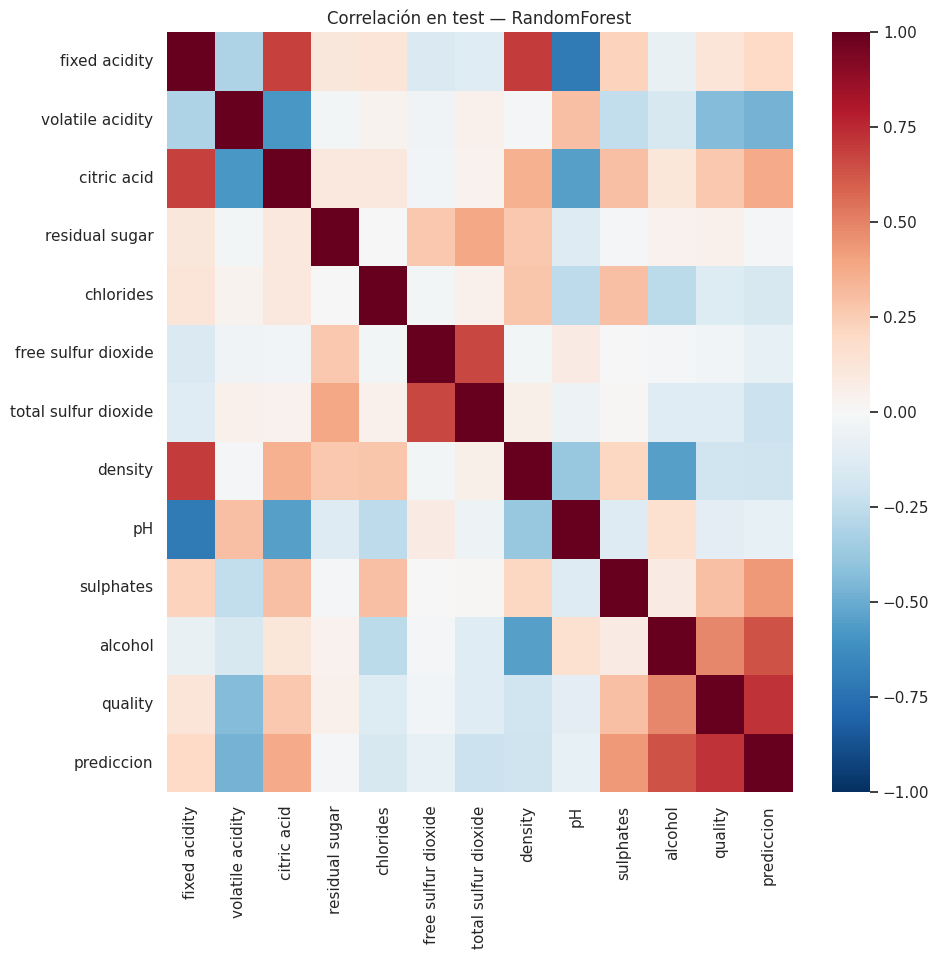

In [10]:
best_name = results.iloc[0]["modelo"]
print(f"Mejor modelo (val): {best_name}")

best_est = MODELS[best_name]
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

best_pipe = Pipeline([("preprocess", preprocess), ("model", best_est)])
best_pipe.fit(X_trainval, y_trainval)
y_pred_test = best_pipe.predict(X_test)

print("Métricas en test (tras reentrenar con train+val):")
display(pd.DataFrame([regression_metrics(y_test, y_pred_test)]).round(4))

# --- Scatter real vs predicho ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_test, alpha=0.5, edgecolors="k", linewidths=0.3)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Valor real")
ax.set_ylabel("Predicción")
ax.set_title(f"{best_name}: real vs predicho (test)")
plt.tight_layout()
plt.show()

# Matriz de correlación en test: target, predicción y features numéricas
_num_test = X_test.select_dtypes(include=[np.number]).columns.tolist()
if len(_num_test) >= 1:
    corr_test = pd.concat(
        [
            X_test[_num_test],
            pd.Series(y_test.values, name=TARGET_COL, index=X_test.index),
            pd.Series(y_pred_test, name="prediccion", index=X_test.index),
        ],
        axis=1,
    ).corr(numeric_only=True)
    size = max(5, 0.75 * len(corr_test.columns))
    fig, ax = plt.subplots(figsize=(size, size))
    sns.heatmap(
        corr_test,
        annot=len(corr_test.columns) <= 12,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        ax=ax,
    )
    ax.set_title(f"Correlación en test — {best_name}")
    plt.tight_layout()
    plt.show()
else:
    print("No hay columnas numéricas en X_test para la matriz de correlación.")





## Checklist: nuevo dataset

1. Coloca el CSV en `data/` y actualiza `DATA_PATH`, `TARGET_COL` y `DROP_COLS`.
2. Revisa faltantes y `dtypes` (celdas de EDA).
3. Ajusta `NUMERIC_COLS` / `CATEGORICAL_COLS` si la detección automática falla.
4. En clasificación, comprueba el balance de clases.
5. Opcional: edita `build_models()` para añadir o quitar algoritmos.
6. Ejecuta todas las celdas y compara la tabla de resultados.
